# Treinar YOLO26 - Gun Detection

Notebook para treinar um modelo **YOLO26** com o dataset **Gun.yolo26** (20.203 imagens, 1 classe: `gun`).

- GPU: NVIDIA GeForce RTX 4060 (8GB VRAM)
- Framework: Ultralytics
- Modelo: YOLO26s (NMS-free, DFL removal, MuSGD optimizer)

## 1. Verificar GPU

In [1]:
!nvidia-smi

Mon Apr 13 23:57:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.97                 Driver Version: 595.97         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060      WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   51C    P8            N/A  /  115W |    1232MiB /   8188MiB |     32%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Instalar Ultralytics + PyTorch CUDA

In [2]:
!pip install ultralytics -q
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124 --upgrade -q


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\hique\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


^C


## 3. Verificar se PyTorch usa CUDA

In [3]:
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


PyTorch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4060


## 4. Preparar Dataset (Split Train/Val)

O dataset Gun.yolo26 so tem a pasta `train`. Vamos separar 10% das imagens para validacao.

In [4]:
import os
import shutil
import random
from pathlib import Path

# Caminhos do dataset
DATASET_DIR = Path('Gun.yolo26')
TRAIN_IMAGES = DATASET_DIR / 'train' / 'images'
TRAIN_LABELS = DATASET_DIR / 'train' / 'labels'
VAL_IMAGES = DATASET_DIR / 'valid' / 'images'
VAL_LABELS = DATASET_DIR / 'valid' / 'labels'

# Verificar se o split ja foi feito
if VAL_IMAGES.exists() and len(list(VAL_IMAGES.glob('*'))) > 0:
    print(f'Split ja realizado! Train: {len(list(TRAIN_IMAGES.glob("*")))} | Val: {len(list(VAL_IMAGES.glob("*")))}')
else:
    # Criar pastas de validacao
    VAL_IMAGES.mkdir(parents=True, exist_ok=True)
    VAL_LABELS.mkdir(parents=True, exist_ok=True)

    # Listar todas as imagens
    all_images = sorted(list(TRAIN_IMAGES.glob('*.jpg')) + list(TRAIN_IMAGES.glob('*.png')))
    print(f'Total de imagens: {len(all_images)}')

    # Selecionar 10% para validacao
    random.seed(42)
    val_count = int(len(all_images) * 0.1)
    val_images = random.sample(all_images, val_count)

    # Mover imagens e labels para validacao
    moved = 0
    for img_path in val_images:
        label_path = TRAIN_LABELS / (img_path.stem + '.txt')
        
        # Mover imagem
        shutil.move(str(img_path), str(VAL_IMAGES / img_path.name))
        
        # Mover label se existir
        if label_path.exists():
            shutil.move(str(label_path), str(VAL_LABELS / label_path.name))
        
        moved += 1

    print(f'Movidas {moved} imagens para validacao')
    print(f'Train: {len(list(TRAIN_IMAGES.glob("*")))} | Val: {len(list(VAL_IMAGES.glob("*")))}')

Split ja realizado! Train: 18183 | Val: 2020


## 5. Criar data.yaml

In [8]:
import yaml
from pathlib import Path

dataset_path = Path('Gun.yolo26').resolve()

data_config = {
    'path': str(dataset_path),
    'train': 'train/images',
    'val': 'valid/images',
    'nc': 1,
    'names': ['gun']
}

data_yaml_path = 'gun_data.yaml'
with open(data_yaml_path, 'w') as f:
    yaml.dump(data_config, f, sort_keys=False)

print(f'Arquivo criado: {data_yaml_path}')
print()
with open(data_yaml_path) as f:
    print(f.read())

ModuleNotFoundError: No module named 'yaml'

## 6. Treinar Modelo

Parametros escolhidos para RTX 4060 (8GB VRAM):
- **Modelo**: `yolo26s.pt` (small - bom equilibrio velocidade/precisao)
- **Epochs**: 50 (dataset grande, 20k+ imagens)
- **Batch**: 16 (cabe na VRAM de 8GB)
- **Imgsz**: 640

> Ajuste `batch` para 8 se der erro de memoria (OOM).

In [5]:

from ultralytics import YOLO

# Carregar modelo pre-treinado YOLO26
model = YOLO('yolo26s.pt')

# Treinar
results = model.train(
    data='gun_data.yaml',
    epochs=10,
    imgsz=640,
    batch=16,
    device=0,
    workers=8,
    project='runs/gun_detect',
    name='train',
    exist_ok=True,
    patience=10,       # early stopping: para se nao melhorar em 10 epochs
    save=True,
    plots=True
)

Ultralytics 8.4.37  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=gun_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspecti

## 7. Resultados do Treinamento

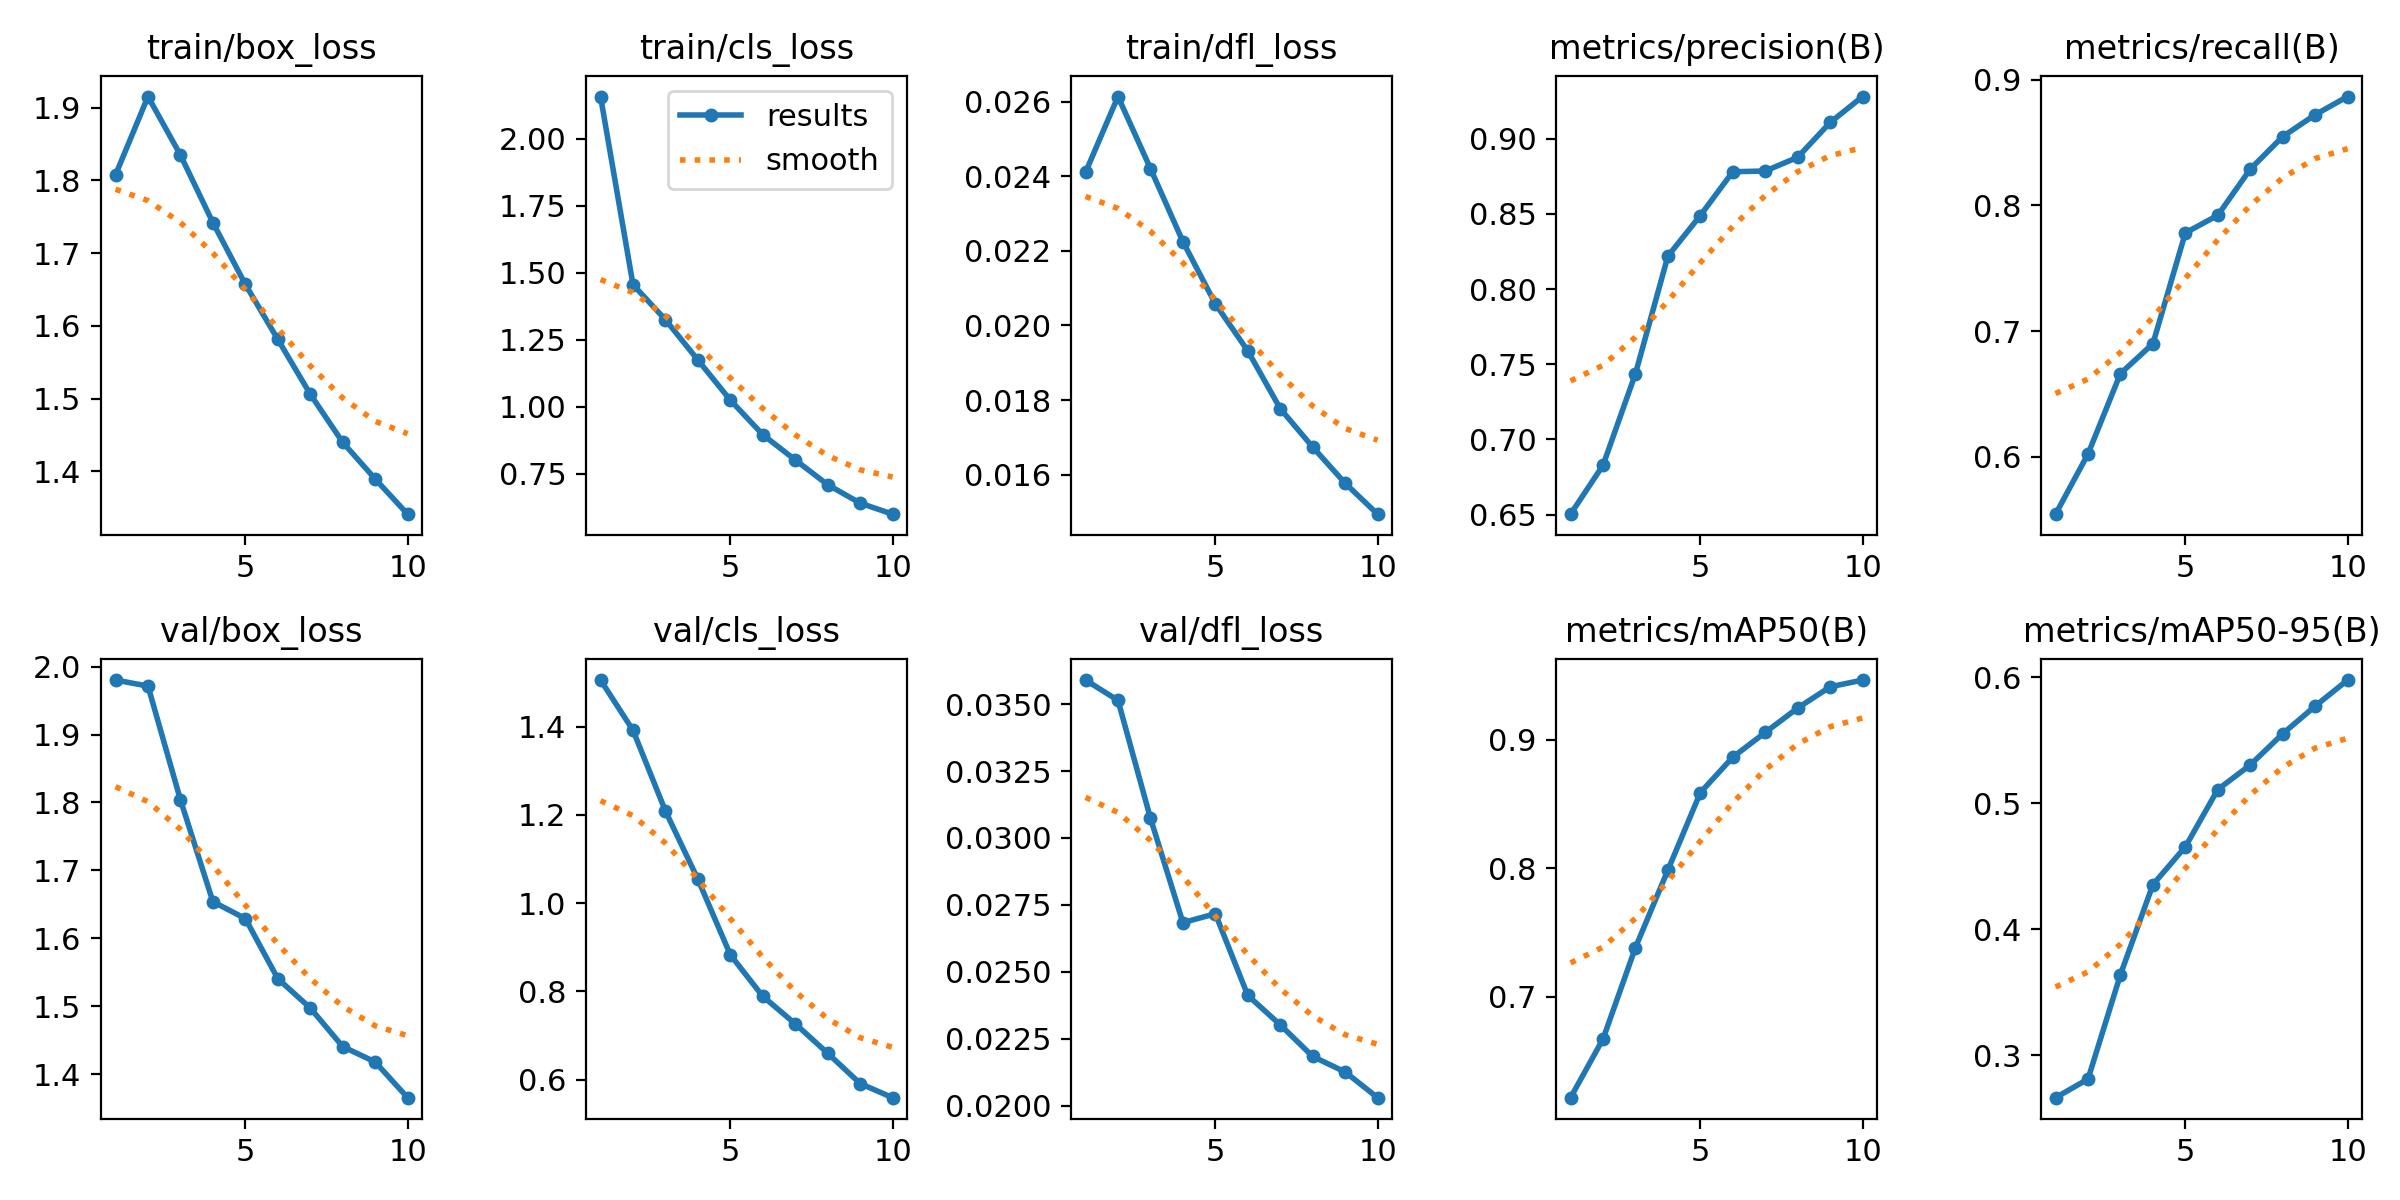

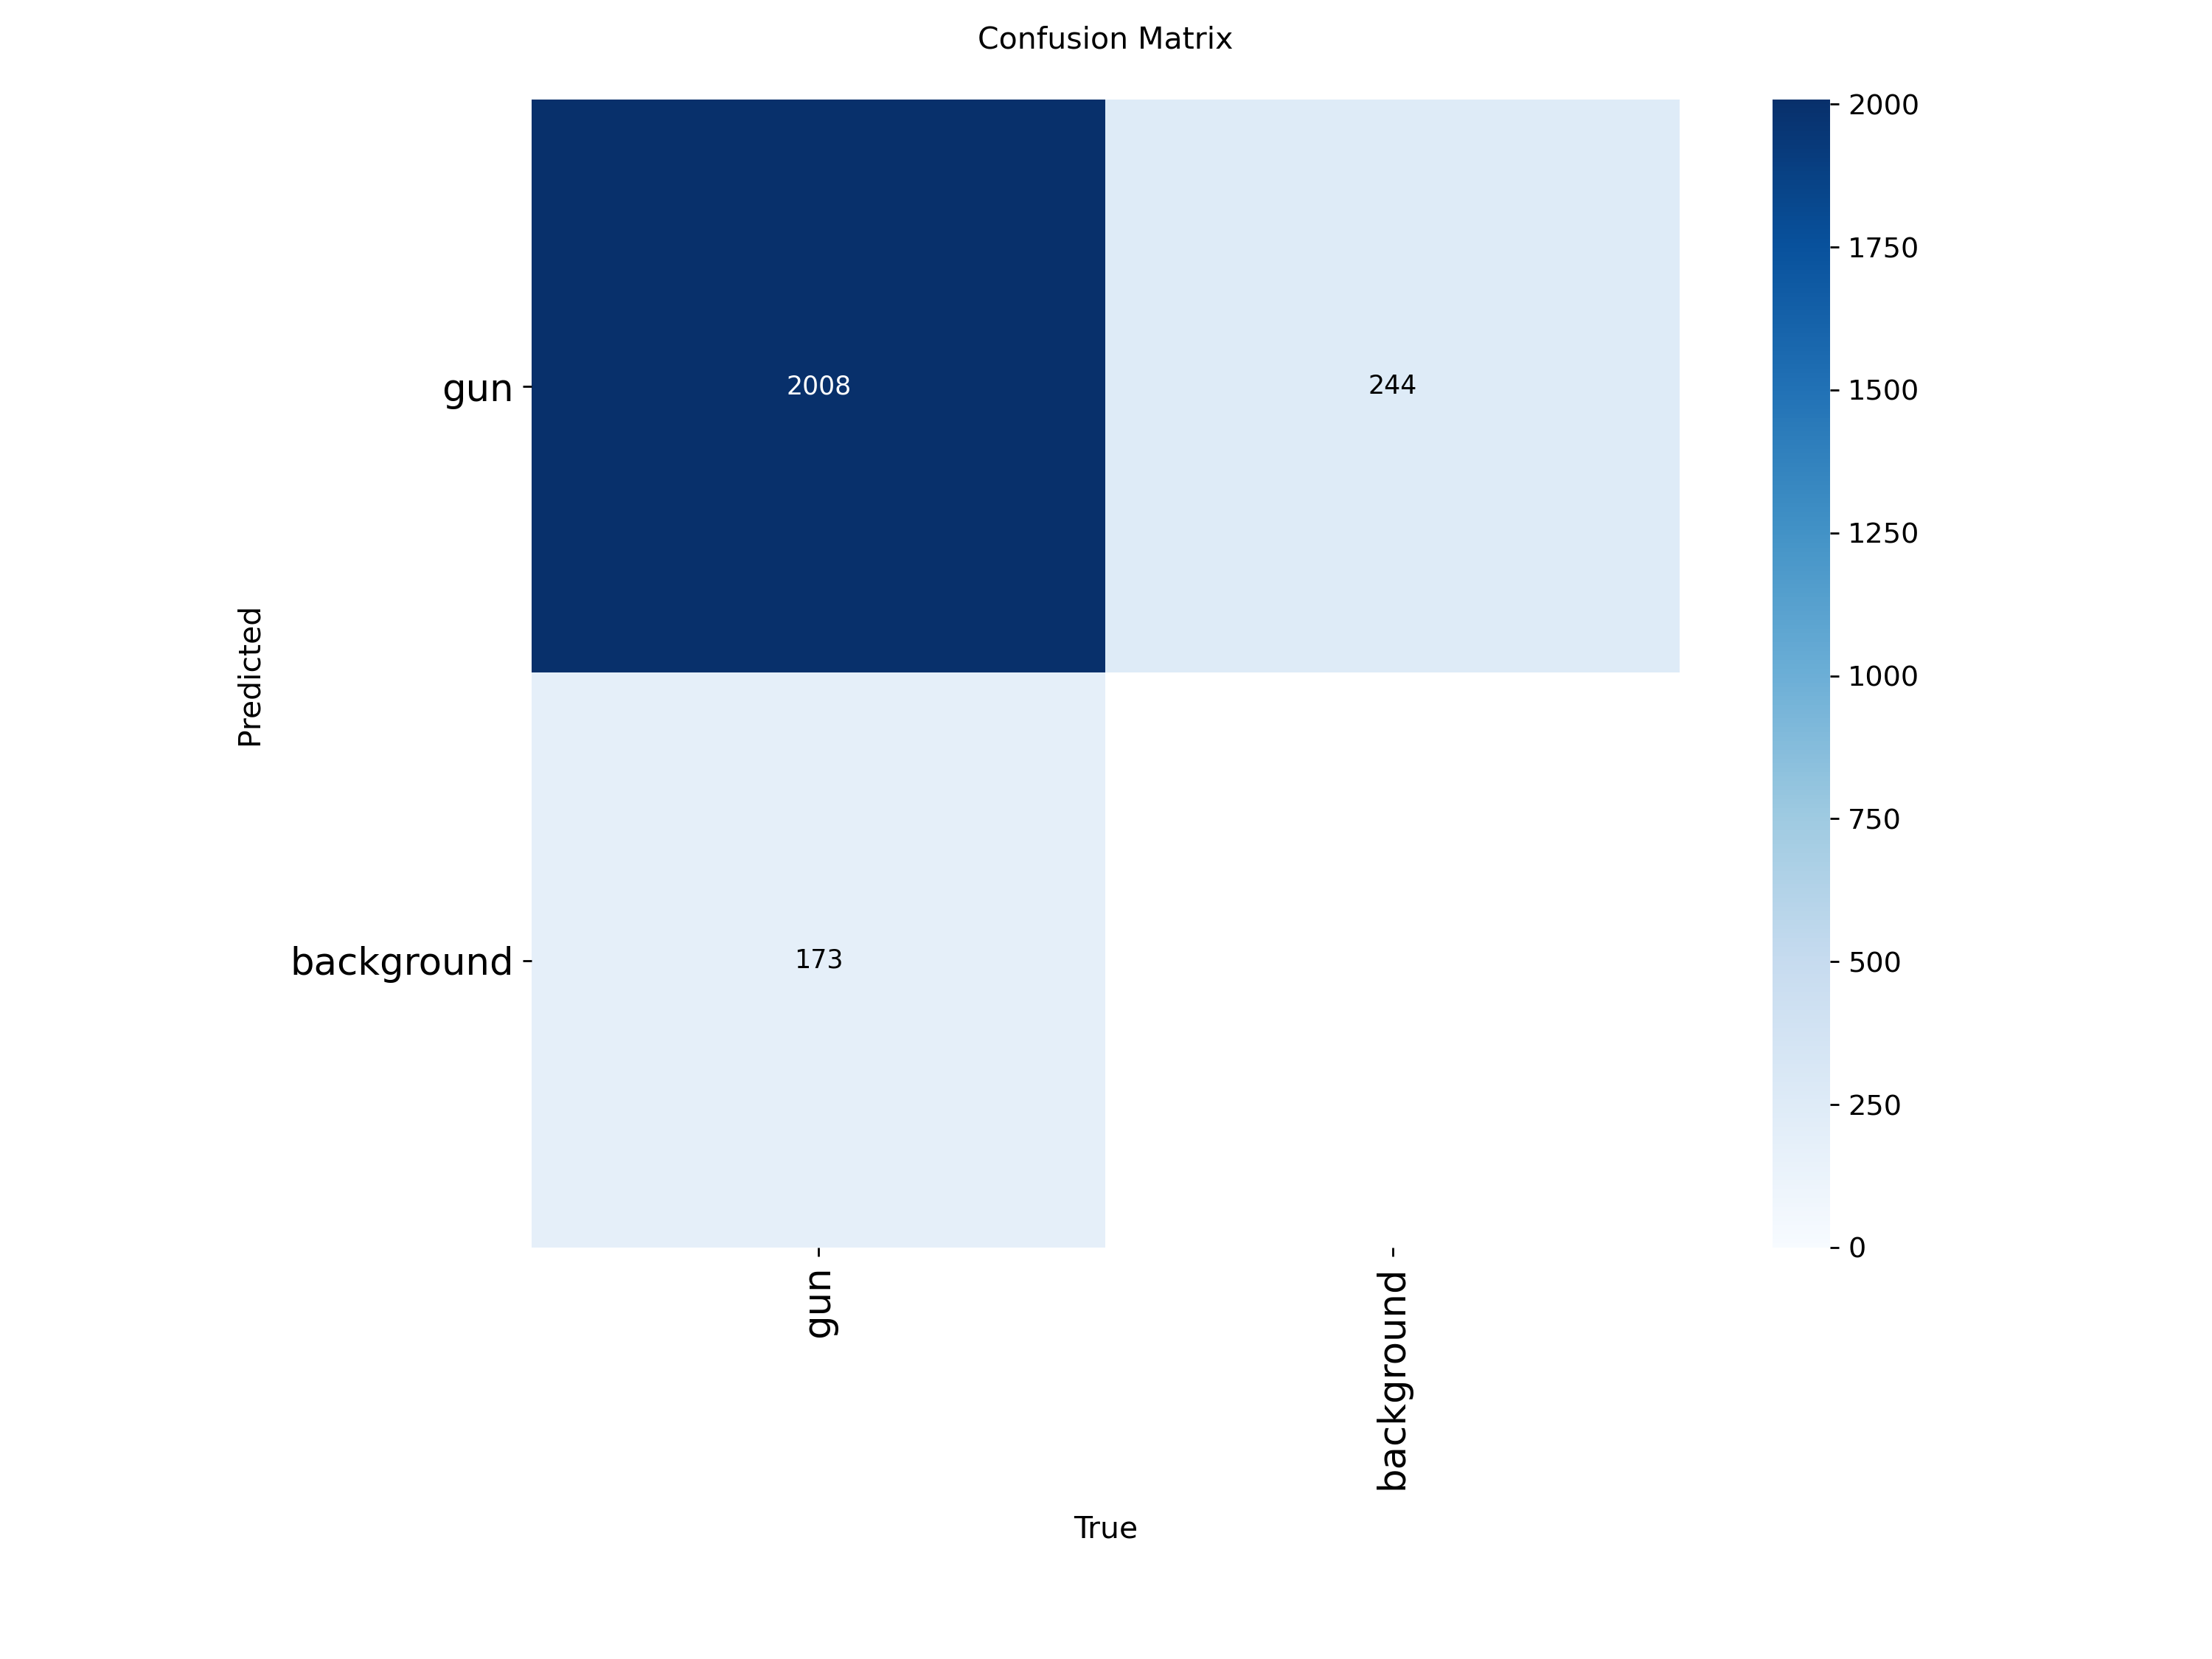

In [9]:
from IPython.display import Image, display
from pathlib import Path

results_dir = Path('runs/detect/runs/gun_detect/train')

# Mostrar curvas de treinamento
results_img = results_dir / 'results.png'
if results_img.exists():
    display(Image(filename=str(results_img), width=900))

# Mostrar matriz de confusao
cm_img = results_dir / 'confusion_matrix.png'
if cm_img.exists():
    display(Image(filename=str(cm_img), width=600))

## 8. Validar Modelo

In [8]:
from ultralytics import YOLO

# Carregar o melhor modelo treinado
best_model = YOLO('runs/detect/runs/gun_detect/train/weights/best.pt')

# Rodar validacao
metrics = best_model.val(data='gun_data.yaml')

print(f"\nmAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

Note: you may need to restart the kernel to use updated packages.
Ultralytics 8.4.37  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access  (ping: 0.10.1 ms, read: 387.8209.5 MB/s, size: 187.2 KB)
val: Scanning C:\Users\hique\Documents\cv\Gun.yolo26\valid\labels.cache... 2020 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2020/2020  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 127/127 6.3it/s 20.2s0.1ss
                   all       2020       2181       0.93      0.884      0.946      0.597
Speed: 0.8ms preprocess, 6.6ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to C:\Users\hique\Documents\cv\runs\detect\val

mAP50: 0.9463
mAP50-95: 0.5974
Precision: 0.9297
Recall: 0.8845


## 9. Testar em Imagens de Validacao

In [10]:
from ultralytics import YOLO
from IPython.display import Image, display
import glob

best_model = YOLO('runs/detect/runs/gun_detect/train/weights/best.pt')

# Predizer nas imagens de validacao
results = best_model.predict(
    source='Gun.yolo26/valid/images',
    save=True,
    project='runs/gun_detect',
    name='predict',
    exist_ok=True,
    conf=0.25
)

# Mostrar as primeiras 10 imagens
pred_images = sorted(glob.glob('runs/gun_detect/predict/*.jpg'))[:10]
for img_path in pred_images:
    display(Image(filename=img_path, height=400))
    print()


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2020 c:\Users\hique\Documents\cv\Gun.yolo26\valid\images\00000121_jpg.rf.yOqUYjHQcnEGg2UYXgK0.jpg: 416x640 2 guns, 44.9ms
image 2/2020 c:\Users\hique\Documents\cv\Gun.yolo26\valid\images\00000151_jpg.rf.JgF29jAFSb0oXinMIzlv.jpg: 384x640 1 gun, 39.6ms
image 3/2020 c:\Users\hique\Documents\cv\Gun.yolo26\valid\images\00000243_jpg.rf.gthkXDmHJxDXqTU9k5il.jpg: 480x640 1 gun, 38.6ms
image 4/2020 c:\Users\hique\Documents\cv\Gun.yolo26\valid\images\00000368

## 10. Exportar Modelo

O melhor modelo fica em: `runs/gun_detect/train/weights/best.pt`

Abaixo voce pode exportar para outros formatos (ONNX, TFLite, etc.).

In [ ]:
from ultralytics import YOLO

model = YOLO('runs/gun_detect/train/weights/best.pt')

# Exportar para ONNX
model.export(format='onnx', imgsz=640)

print('Modelo exportado com sucesso!')

Note: you may need to restart the kernel to use updated packages.



ERROR: Could not find a version that satisfies the requirement PIL (from versions: none)
ERROR: No matching distribution found for PIL

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


image 1/1 c:\Users\hique\Documents\cv\testing\images.jpg: 480x640 1 gun, 361.2ms
Speed: 153.3ms preprocess, 361.2ms inference, 24.1ms postprocess per image at shape (1, 3, 480, 640)
Results saved to C:\Users\hique\Documents\cv\runs\detect\runs\gun_detect\test_predict
Predicoes: tensor([[ 53.8090,  52.8773,  91.1225, 118.2347]], device='cuda:0')
Confianças: tensor([0.7273], device='cuda:0')
Classes: tensor([0.], device='cuda:0')


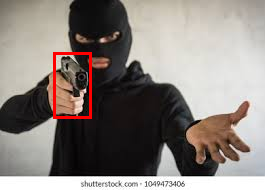

Imagem com bbox salva em testing/test_image_bbox.jpg


In [16]:
%pip install PIL
#Predizer em uma imagem teste que baixei da internet em /testing/

predict = model.predict(source='testing', save=True, project='runs/gun_detect', name='test_predict', exist_ok=True, conf=0.25)

result =  predict[0]  # pegar o resultado da primeira imagem

print(f"Predicoes: {result.boxes.xyxy}")
print(f"Confianças: {result.boxes.conf}")
print(f"Classes: {result.boxes.cls}")

#Desenhar a bounding box usando ImageDraw do PIL
from PIL import Image, ImageDraw
img_path = 'testing/images.jpg'  # caminho da imagem teste
img = Image.open(img_path)
draw = ImageDraw.Draw(img)
for box in result.boxes.xyxy:
    x1, y1, x2, y2 = box
    draw.rectangle([x1, y1, x2, y2], outline='red', width=3)
display(img)  # mostra no notebook
img.save('testing/test_image_bbox.jpg')
print('Imagem com bbox salva em testing/test_image_bbox.jpg')
